# Phase 2: EDA and Stationarity Checks
This notebook performs data quality checks, returns analysis, and ADF stationarity tests.

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings('ignore')

DATA_DIR = Path('../data')
OUT_DIR = Path('../outputs')
OUT_DIR.mkdir(parents=True, exist_ok=True)

prices = pd.read_csv(DATA_DIR / 'nifty_prices_clean.csv', index_col=0, parse_dates=True)
with open(DATA_DIR / 'sectors.json', 'r') as f:
    sectors = json.load(f)

print(f'Loaded prices shape: {prices.shape}')
print(f'Date range: {prices.index.min().date()} to {prices.index.max().date()}')
print(f'Missing values: {int(prices.isna().sum().sum())}')

Loaded prices shape: (2467, 22)
Date range: 2015-01-01 to 2024-12-31
Missing values: 0


In [2]:
# Time-based split (no shuffling for time series)
train = prices.loc['2015-01-01':'2021-12-31'].copy()
valid = prices.loc['2022-01-01':'2023-12-31'].copy()
test = prices.loc['2024-01-01':'2025-12-31'].copy()

print('Split summary:')
print(f'  Train: {train.index.min().date()} to {train.index.max().date()} | rows={len(train)}')
print(f'  Valid: {valid.index.min().date()} to {valid.index.max().date()} | rows={len(valid)}')
print(f'  Test : {test.index.min().date()} to {test.index.max().date()} | rows={len(test)}')

Split summary:
  Train: 2015-01-01 to 2021-12-31 | rows=1728
  Valid: 2022-01-03 to 2023-12-29 | rows=493
  Test : 2024-01-01 to 2024-12-31 | rows=246


In [3]:
# Returns for EDA and later feature engineering
log_returns = np.log(prices / prices.shift(1)).dropna()
train_returns = log_returns.loc[train.index.min():train.index.max()].copy()

print('Returns summary:')
display(train_returns.describe().T[['mean', 'std', 'min', 'max']].head())

Returns summary:


,mean,std,min,max
AXISBANK.NS,0.000190,0.023526,-0.327266,0.177985
BAJAJ-AUTO.NS,0.000270,0.016464,-0.147111,0.114316
BANKBARODA.NS,-0.000546,0.028529,-0.178853,0.273347
COALINDIA.NS,-0.000218,0.018229,-0.083446,0.077910
EICHERMOT.NS,0.000328,0.021157,-0.134461,0.125576


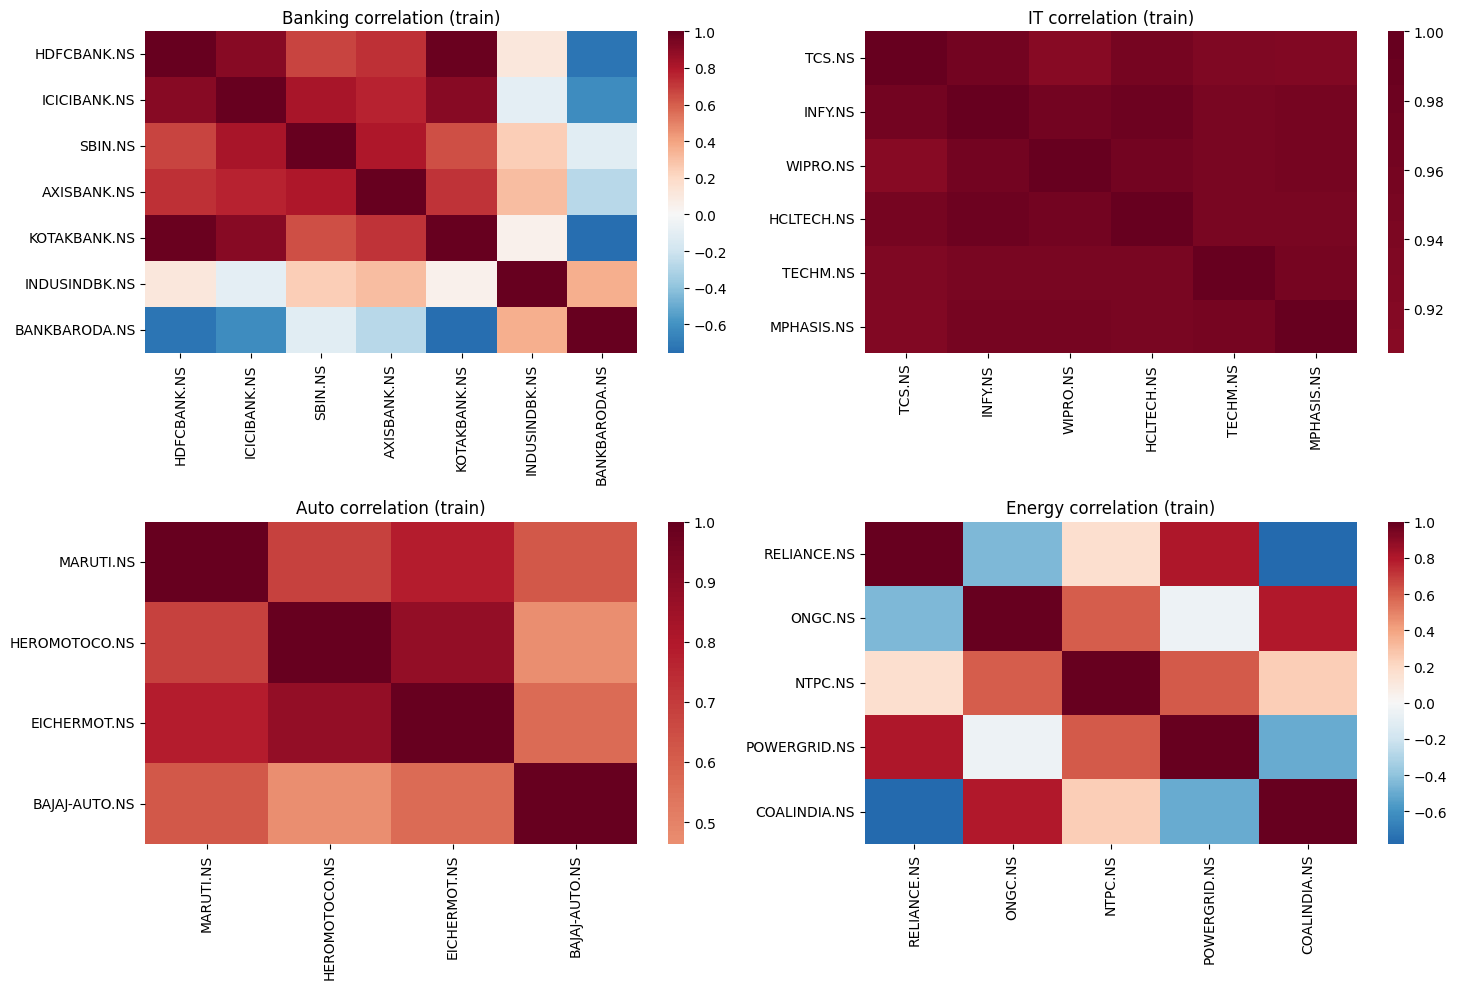

Saved: ../outputs/03_sector_heatmaps_train.png


In [4]:
# Sector-wise train correlation heatmaps
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (sector_name, tickers) in enumerate(sectors.items()):
    ax = axes[idx]
    cols = [t for t in tickers if t in train.columns]
    corr = train[cols].corr()
    sns.heatmap(corr, cmap='RdBu_r', center=0, annot=False, ax=ax)
    ax.set_title(f'{sector_name} correlation (train)')

plt.tight_layout()
plt.savefig(OUT_DIR / '03_sector_heatmaps_train.png', dpi=140, bbox_inches='tight')
plt.show()
print('Saved: ../outputs/03_sector_heatmaps_train.png')

In [5]:
# ADF tests on level prices in train period
def adf_pvalue(series: pd.Series) -> float:
    result = adfuller(series.dropna(), autolag='AIC')
    return float(result[1])

adf_rows = []
for ticker in train.columns:
    pval = adf_pvalue(train[ticker])
    adf_rows.append({'ticker': ticker, 'adf_pvalue_level': pval})

adf_df = pd.DataFrame(adf_rows).sort_values('adf_pvalue_level')
adf_df['is_non_stationary_at_5pct'] = adf_df['adf_pvalue_level'] > 0.05

display(adf_df.head(10))
print(f'Non-stationary at 5%: {adf_df.is_non_stationary_at_5pct.mean():.2%}')

adf_df.to_csv(DATA_DIR / 'adf_levels_train.csv', index=False)
print('Saved: ../data/adf_levels_train.csv')

,ticker,adf_pvalue_level,is_non_stationary_at_5pct
4,EICHERMOT.NS,0.200359,True
2,BANKBARODA.NS,0.202586,True
7,HEROMOTOCO.NS,0.205916,True
0,AXISBANK.NS,0.215786,True
15,ONGC.NS,0.218396,True
14,NTPC.NS,0.225855,True
12,MARUTI.NS,0.321642,True
3,COALINDIA.NS,0.367853,True
9,INDUSINDBK.NS,0.472210,True
1,BAJAJ-AUTO.NS,0.482652,True


Non-stationary at 5%: 100.00%
Saved: ../data/adf_levels_train.csv


In [6]:
# Save split data for downstream notebooks
train.to_csv(DATA_DIR / 'prices_train.csv')
valid.to_csv(DATA_DIR / 'prices_valid.csv')
test.to_csv(DATA_DIR / 'prices_test.csv')
log_returns.to_csv(DATA_DIR / 'log_returns_all.csv')

print('Saved split datasets and returns for next phases.')

Saved split datasets and returns for next phases.
